# titiler-cmr: timeseries capabilities

There is a family of `/timeseries` endpoints in the `titiler.cmr` API that can be used to generate time-aware responses.

In [10]:
from IPython.display import IFrame

# if running titiler-cmr in the docker network
titiler_endpoint = "http://localhost:8081"
# titiler_endpoint = "https://9ox7r6pi8c.execute-api.us-west-2.amazonaws.com"

IFrame(f"{titiler_endpoint}/api.html#Timeseries", 900, 500)

In [12]:
import json
from datetime import datetime

import httpx
import matplotlib.pyplot as plt
import numpy as np
from folium import LayerControl, Map, TileLayer
from geojson_pydantic import Feature, Polygon
from IPython.display import Image, display

## timeseries API

The timeseries API makes it possible to return results for many points along a timeseries with a single request.
The available parameters are:
- **`start_datetime`** (str): beginning of datetime range in ISO format
- **`end_datetime`** (str): end of datetime range in ISO format
- **`step`** (str): width of individual timesteps expressed as a IS8601 duration
- **`step_idx`** (int): base-zero index of individual step
- **`exact`** (bool): if `True`, queries will be made for a specific point in time at each step. If `False`, queries will be made for the entire interval between steps.
- **`datetime`** (str): comma-separated list of strings representing the times or time intervals that you want to query

There are many ways to combine the parameters to produce a timeseries.

1. Exact points in time from a start to and end datetime:
  - provide `start_datetime`, `end_datetime`, `step`, and `exact=True`
2. Fixed-width intervals between a start and end datetime:
  - provide `start_datetime`, `end_datetime`, `step`, and `exact=False`
3. Specific datetimes
  - provide `datetimes=2024-10-01T00:00:01Z,2024-10-02T00:00:01Z`
4. Specific datetime intervals
  - provide `datetimes=2024-10-01T00:00:01Z/2024-10-01T23:59:59Z,2024-10-05T00:00:01Z/2024-10-05T23:59:59Z`


## How to use the timeseries API with `titiler.cmr`

The `/timeseries` endpoints work by interpreting the timeseries parameters (e.g. `start_datetime` and `end_datetime`) and parameterizing a set of lower-level requests to the related endpoint. For example, a request to `/timeseries/statistics` for a set of four timepoints each one week apart will fire off four requests to the `/statistics` endpoint with a particular value in the `datetime` parameter. The results are collected and returned in a coherent format that can be consumed in a table or a chart. 

Every `/timeseries` request in `titiler.cmr` will require both a `concept_id` and a set of timeseries parameters. The [GHRSST Level 4 GAMSSA_28km Global Foundation Sea Surface Temperature Analysis v1.0 dataset (GDS2)](https://cmr.earthdata.nasa.gov/search/concepts/C2036881735-POCLOUD.html) is a useful dataset for demo purposes because the granule assets are small (~1MB each).



In [13]:
concept_id = "C2036881735-POCLOUD"

The `/timeseries` `GET` endpoint is useful for demonstrating how the timeseries family of endpoints constructs sub-requests. It returns the list of `titiler.cmr` query parameters (`datetime` and `concept_id`) that will be used to generate the timeseries results.

### Timeseries for all granules between a start/end datetime

For some datasets that have granules that are regularly spaced in time (e.g. daily), it is useful to be able to quickly specify a summary of all timepoints between a start and end datetime. You can do that by simply providing the `start_datetime` and `end_datetime` parameters. The application will query CMR and produce a list of unique `datetime` values from the results of the granule search. If a granule represents a datetime range, it will return the midpoint between the start and end for a single granule.

In [14]:
response = httpx.get(
    f"{titiler_endpoint}/timeseries",
    params={
        "concept_id": concept_id,
        "start_datetime": "2024-10-01T00:00:01Z",
        "end_datetime": "2024-10-05T00:00:01Z",
    },
    timeout=None,
).json()

print(json.dumps(response, indent=2))

[
  {
    "concept_id": "C2036881735-POCLOUD",
    "datetime": "2024-10-01T12:00:00+00:00"
  },
  {
    "concept_id": "C2036881735-POCLOUD",
    "datetime": "2024-10-02T12:00:00+00:00"
  },
  {
    "concept_id": "C2036881735-POCLOUD",
    "datetime": "2024-10-03T12:00:00+00:00"
  },
  {
    "concept_id": "C2036881735-POCLOUD",
    "datetime": "2024-10-04T12:00:00+00:00"
  },
  {
    "concept_id": "C2036881735-POCLOUD",
    "datetime": "2024-10-05T12:00:00+00:00"
  }
]


### Weekly timeseries

Sometimes you might be interested in a report with lower temporal resolution than the full dataset timeseries. By setting `step="P1W"` and `exact=True`, you can get a weekly series.

In [15]:
response = httpx.get(
    f"{titiler_endpoint}/timeseries",
    params={
        "concept_id": concept_id,
        "start_datetime": "2024-10-01T00:00:01Z",
        "end_datetime": "2024-10-30T00:00:01Z",
        "step": "P1W",
        "exact": True,
    }
).json()

print(json.dumps(response, indent=2))

[
  {
    "concept_id": "C2036881735-POCLOUD",
    "datetime": "2024-10-01T00:00:01+00:00"
  },
  {
    "concept_id": "C2036881735-POCLOUD",
    "datetime": "2024-10-08T00:00:01+00:00"
  },
  {
    "concept_id": "C2036881735-POCLOUD",
    "datetime": "2024-10-15T00:00:01+00:00"
  },
  {
    "concept_id": "C2036881735-POCLOUD",
    "datetime": "2024-10-22T00:00:01+00:00"
  },
  {
    "concept_id": "C2036881735-POCLOUD",
    "datetime": "2024-10-29T00:00:01+00:00"
  }
]


### Periodic timeseries

Some datasets (like satellite imagery) may consist of granules that do not fully cover an arbitrary area of interest. In this case it is useful to construct a timeseries from a set of datetime ranges so that granules can be mosaiced to ensure each step has full coverage.

To create a set of non-overlapping week-long datetime ranges, you can modify the query to use `exact=False` which will create ranges that start on the weekly values returned in the previous query and extend up to the second before the next value in the series.

In [16]:
response = httpx.get(
    f"{titiler_endpoint}/timeseries",
    params={
        "concept_id": concept_id,
        "start_datetime": "2024-10-01T00:00:01Z",
        "end_datetime": "2024-10-30T00:00:01Z",
        "step": "P1W",
        "exact": False,
    }
).json()

print(json.dumps(response, indent=2))

[
  {
    "concept_id": "C2036881735-POCLOUD",
    "datetime": "2024-10-01T00:00:01+00:00/2024-10-08T00:00:00+00:00"
  },
  {
    "concept_id": "C2036881735-POCLOUD",
    "datetime": "2024-10-08T00:00:01+00:00/2024-10-15T00:00:00+00:00"
  },
  {
    "concept_id": "C2036881735-POCLOUD",
    "datetime": "2024-10-15T00:00:01+00:00/2024-10-22T00:00:00+00:00"
  },
  {
    "concept_id": "C2036881735-POCLOUD",
    "datetime": "2024-10-22T00:00:01+00:00/2024-10-29T00:00:00+00:00"
  },
  {
    "concept_id": "C2036881735-POCLOUD",
    "datetime": "2024-10-29T00:00:01+00:00/2024-10-30T00:00:01+00:00"
  }
]


### Custom timeseries
If you want to specify the exact datetime values for a timeseries and you either cannot do not want to use the timeseries parameters, you can supply a set of comma-separated datetimes and/or datetime ranges to the `datetimes` parameter.

In [17]:
response = httpx.get(
    f"{titiler_endpoint}/timeseries",
    params={
        "concept_id": concept_id,
        "datetimes": ",".join(
            ["2024-10-01T00:00:01Z", "2024-10-07T00:00:01Z/2024-10-09:23:59:59Z"]
        ),
    }
).json()

print(json.dumps(response, indent=2))

[
  {
    "concept_id": "C2036881735-POCLOUD",
    "datetime": "2024-10-01T00:00:01Z"
  },
  {
    "concept_id": "C2036881735-POCLOUD",
    "datetime": "2024-10-07T00:00:01Z/2024-10-09:23:59:59Z"
  }
]


## Example: sea surface temperature GIF

The `/timeseries/bbox` endpoint can be used to produce a GIF that shows a visualization of granules over time.  

The example below shows biweekly sea surface temperature estimates from the GAMSSA dataset for the period from November 2023 thru October 2024.

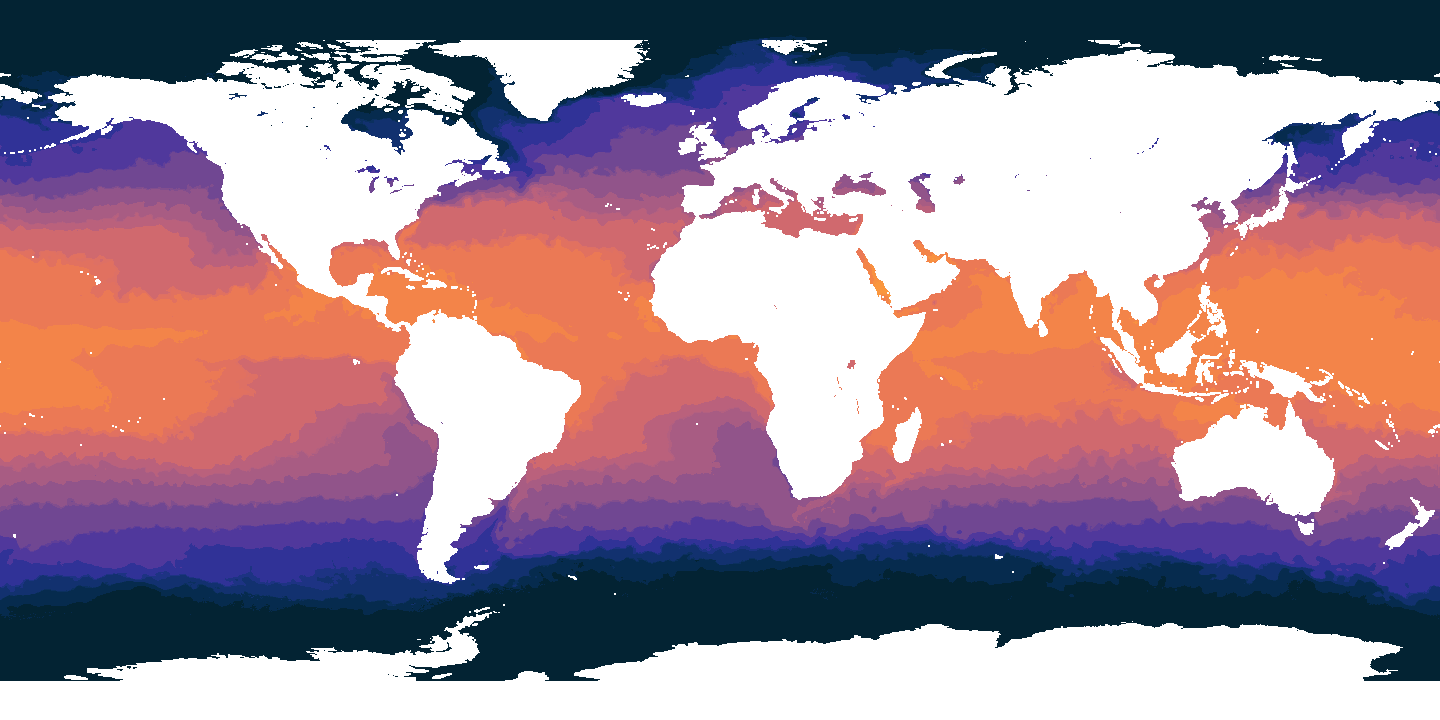

In [18]:
minx, miny, maxx, maxy = -180, -90, 180, 90
request = httpx.get(
    f"{titiler_endpoint}/timeseries/bbox/{minx},{miny},{maxx},{maxy}.gif",
    params={
        "concept_id": concept_id,
        "start_datetime": "2023-11-01T00:00:01Z",
        "end_datetime": "2024-10-30T23:59:59Z",
        "step": "P2W",
        "exact": True,
        "variable": "analysed_sst",
        "backend": "xarray",
        "colormap_name": "thermal",
        "rescale": [[273, 315]],
    },
    timeout=None,
)

display(Image(request.content))

## Example: sea surface temperature statistics
The `/timeseries/statistics` endpoint will produce summary statistics for an AOI for all points along a timeseries.

The example below shows biweekly sea surface temperature summary statistics for the Gulf of Mexico from the GAMSSA dataset for the period from November 2023 thru October 2024.

In [7]:
minx, miny, maxx, maxy = -98.676, 18.857, -81.623, 31.097
geojson = Feature(
    type="Feature",
    geometry=Polygon.from_bounds(minx, miny, maxx, maxy),
    properties={},
)
request = httpx.post(
    f"{titiler_endpoint}/timeseries/statistics",
    params={
        "concept_id": concept_id,
        "start_datetime": "2023-11-01T00:00:01Z",
        "end_datetime": "2024-10-30T23:59:59Z",
        "step": "P2W",
        "exact": True,
        "variable": "analysed_sst",
        "backend": "xarray",
    },
    json=geojson.model_dump(exclude_none=True),
    timeout=None,
)

response = request.json()

The `/timeseries/statistics` endpoint returns the GeoJSON with statistics for each step in the timeseries embedded in the properties.

In [8]:
stats = response["properties"]["statistics"]

stats_preview = {timestamp: sst_stats for i, (timestamp, sst_stats) in enumerate(stats.items()) if i < 2}
print(json.dumps(stats_preview, indent=2))

{
  "2023-11-01T00:00:01+00:00": {
    "analysed_sst": {
      "min": 296.68000000000006,
      "max": 303.37,
      "mean": 300.8925778874482,
      "count": 2337.9599609375,
      "sum": 703474.7996441221,
      "std": 1.2819886030815113,
      "median": 301.09000000000003,
      "majority": 301.04,
      "minority": 296.68000000000006,
      "unique": 542.0,
      "histogram": [
        [
          39,
          56,
          58,
          108,
          226,
          386,
          598,
          444,
          276,
          172
        ],
        [
          296.68000000000006,
          297.34900000000005,
          298.01800000000003,
          298.68700000000007,
          299.35600000000005,
          300.02500000000003,
          300.694,
          301.363,
          302.03200000000004,
          302.701,
          303.37
        ]
      ],
      "valid_percent": 69.89,
      "masked_pixels": 1018.0,
      "valid_pixels": 2363.0,
      "percentile_2": 297.49,
      "percent

The statistics output can be used to generate plots like this:

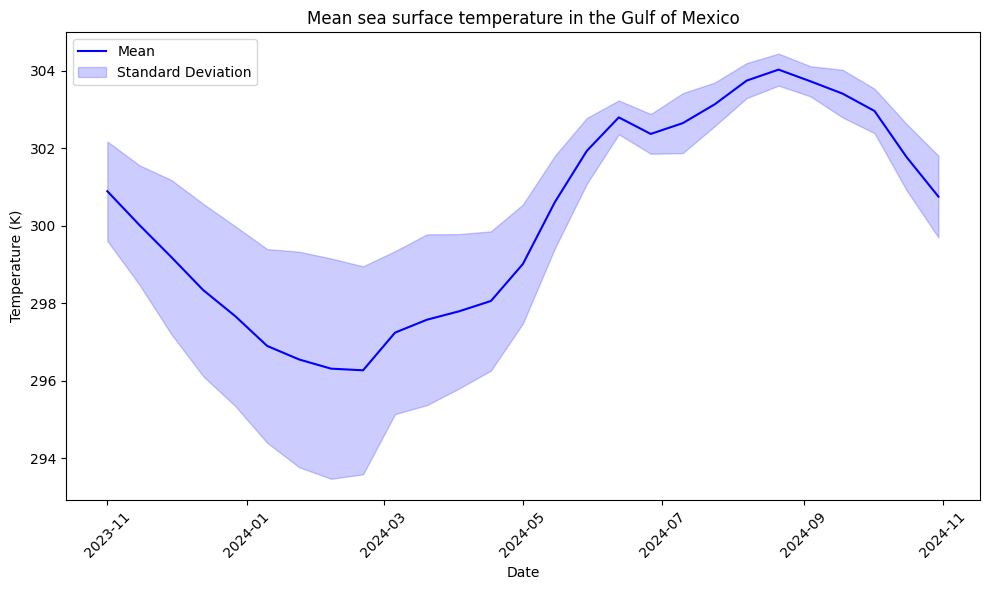

In [9]:
data = response['properties']['statistics']

dates = []
means = []
stds = []

for date_str, values in data.items():
    dates.append(datetime.fromisoformat(date_str))
    means.append(values["analysed_sst"]["mean"])
    stds.append(values["analysed_sst"]["std"])

plt.figure(figsize=(10, 6))

plt.plot(dates, means, "b-", label="Mean")

plt.fill_between(
    dates, 
    np.array(means) - np.array(stds),
    np.array(means) + np.array(stds),
    alpha=0.2,
    color="b",
    label="Standard Deviation",
)

plt.xlabel("Date")
plt.ylabel("Temperature (K)")
plt.title("Mean sea surface temperature in the Gulf of Mexico")
plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## Example: Timeseries raster tiles

It could be useful to allow users to select a timestep in an interactive map. You can use the `/timeseries/tilejson` endpoint for that purpose. The following example shows how you could use it to provide timeseries capability to an interactive map of sea ice cover.

In [19]:
minx, miny, maxx, maxy = -180, -90, 180, 90
request = httpx.get(
    f"{titiler_endpoint}/timeseries/WebMercatorQuad/tilejson.json",
    params={
        "concept_id": concept_id,
        "start_datetime": "2023-11-01T00:00:01Z",
        "end_datetime": "2024-10-30T23:59:59Z",
        "step": "P1M",
        "exact": True,
        "variable": "sea_ice_fraction",
        "backend": "xarray",
        "colormap_name": "blues_r",
        "rescale": [[0, 1]],
    },
    timeout=None,
)
tilejsons = request.json()
tilejson_preview = {timestamp: tilejson for i, (timestamp, tilejson) in enumerate(tilejsons.items()) if i < 2}
print(json.dumps(tilejson_preview, indent=2))

{
  "2023-11-01T00:00:01+00:00": {
    "tilejson": "2.2.0",
    "version": "1.0.0",
    "scheme": "xyz",
    "tiles": [
      "http://localhost:8081/tiles/WebMercatorQuad/{z}/{x}/{y}@1x?concept_id=C2036881735-POCLOUD&variable=sea_ice_fraction&backend=xarray&colormap_name=blues_r&rescale=%5B0%2C+1%5D&datetime=2023-11-01T00%3A00%3A01%2B00%3A00"
    ],
    "minzoom": 0,
    "maxzoom": 24,
    "bounds": [
      -180.0,
      -90.0,
      180.0,
      90.0
    ],
    "center": [
      0.0,
      0.0,
      0
    ]
  },
  "2023-12-01T00:00:01+00:00": {
    "tilejson": "2.2.0",
    "version": "1.0.0",
    "scheme": "xyz",
    "tiles": [
      "http://localhost:8081/tiles/WebMercatorQuad/{z}/{x}/{y}@1x?concept_id=C2036881735-POCLOUD&variable=sea_ice_fraction&backend=xarray&colormap_name=blues_r&rescale=%5B0%2C+1%5D&datetime=2023-12-01T00%3A00%3A01%2B00%3A00"
    ],
    "minzoom": 0,
    "maxzoom": 24,
    "bounds": [
      -180.0,
      -90.0,
      180.0,
      90.0
    ],
    "center": [
   

In [20]:
m = Map(location=[0, 0], zoom_start=3, min_zoom=3)
for datetime_, tilejson in tilejsons.items():
    label = datetime.fromisoformat(datetime_).strftime("%Y-%m")
    TileLayer(
        tiles=tilejson["tiles"][0],
        attr="GAMSSA SST",
        overlay=True,
        name=label,
        show=False,
    ).add_to(m)
LayerControl(collapsed=False).add_to(m)
m